In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
from scipy import stats
from sklearn.model_selection import train_test_split
from typing import Union
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.ensemble import RandomForestRegressor


In [90]:
#url = "https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/master/data/SaratogaHouses.csv"
url = "https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/master/data/state_x77.csv"
df = pd.read_csv(url)

df.head()

,habitantes,ingresos,analfabetismo,esp_vida,asesinatos,universitarios,heladas,area,densidad_pobl
0,3615,3624,2.1,69.05,15.1,41.3,20,50708,71.290526
1,365,6315,1.5,69.31,11.3,66.7,152,566432,0.644384
2,2212,4530,1.8,70.55,7.8,58.1,15,113417,19.503249
3,2110,3378,1.9,70.66,10.1,39.9,65,51945,40.619886
4,21198,5114,1.1,71.71,10.3,62.6,20,156361,135.570890


In [91]:
df.dtypes

habitantes          int64
ingresos            int64
analfabetismo     float64
esp_vida          float64
asesinatos        float64
universitarios    float64
heladas             int64
area                int64
densidad_pobl     float64
dtype: object

In [92]:
df.shape


(50, 9)

In [93]:
X = df.drop(columns=["esp_vida"]) #predictoras
y = df["esp_vida"] #objetivo

In [94]:
#scaler = StandardScaler() #dev estandar = 1  media = 0
#X = scaler.fit_transform(X)

In [95]:
scaler = MinMaxScaler()  #Rango 0 a 1
X = scaler.fit_transform(X)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [97]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [98]:
modelo.intercept_

72.29768566075809

In [99]:
modelo.coef_

array([ 1.48731309,  1.09019298,  0.49491431, -4.53859654,  0.91571456,
       -1.1448764 , -0.63241167, -1.02254895])

In [100]:
y_pred = modelo.predict(X_test)

In [101]:
error = root_mean_squared_error(y_test, y_pred)
error

0.6714427752718688

In [102]:
errorabs = mean_absolute_error(y_test, y_pred)
errorabs

0.5479584523345664

In [103]:
R2 = modelo.score(X_test, y_test)
R2

0.4756898759980799

In [104]:
m_correlation = df.corr()

<Axes: >

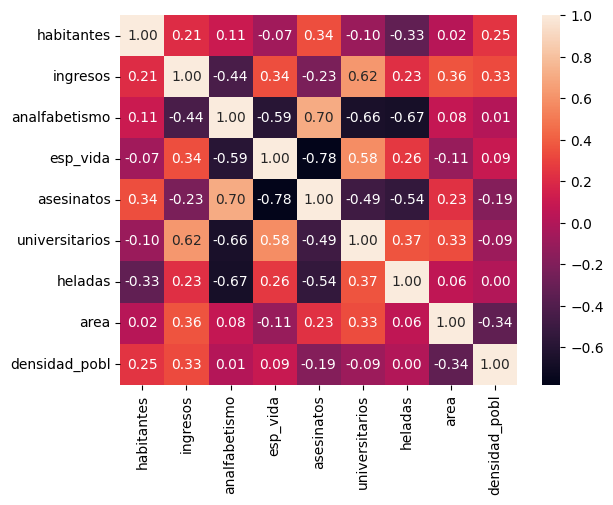

In [105]:
sns.heatmap(df.corr(),annot=True, fmt=".2f")

0.9854775601887454
0.7572306019917405
0.5837159955457243


<Axes: >

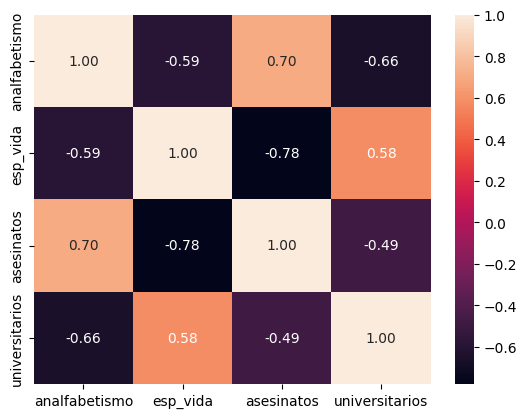

In [108]:
threshold = 0.5
seleccionadas = m_correlation["esp_vida"][abs(m_correlation["esp_vida"]) > threshold].index

df_filtrado = df[seleccionadas]
df_filtrado.head()

X = df_filtrado.drop(columns=["esp_vida"]) #predictoras
y = df_filtrado["esp_vida"] #objetivo
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
error = root_mean_squared_error(y_test, y_pred)
print(error)
errorabs = mean_absolute_error(y_test, y_pred)
print(errorabs)
R2 = modelo.score(X_test, y_test)
print(R2)

sns.heatmap(df_filtrado.corr(),annot=True, fmt=".2f")

In [115]:
modelo_rf = RandomForestRegressor(n_estimators=10, criterion='squared_error', max_depth= 20)
modelo_rf.fit(X_train, y_train)
y_pred = modelo_rf.predict(X_test)
error = root_mean_squared_error(y_test, y_pred)
print(error)
errorabs = mean_absolute_error(y_test, y_pred)
print(errorabs)
R2 = modelo.score(X_test, y_test)
print(R2)


0.8861769010756287
0.7831000000000004
0.5837159955457243
